# Imports

In [33]:
from importlib import reload
import ActivationPrototypes_SARSeg.thesis_utils as utils
reload(utils)
from ActivationPrototypes_SARSeg.thesis_utils import *
from torch.utils.data import DataLoader

# Setup

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lmdb_path = '../data/Encoded-BigEarthNet'
parquet_path = '../data/metadata.parquet'

model128 = load_from_checkpoint("../models/unet_epoch_20.pth").to(device)
model120 = load_from_checkpoint120("../models/first_try/unet120_epoch_2.pth").to(device)
model_untrained = load_base_with_bigearth_pretrained120().to(device)
model_120short = load_from_checkpoint120("../models/short10k/unet120_10k_epoch_10.pth").to(device)
model_120_full = load_from_checkpoint120("../models/full_120/unet120_full_epoch_19.pth").to(device)

indices = [458, 155, 163, 424, 396]

c:\Users\Jean\anaconda3\envs\ActivationPrototypes_SARSeg\lib\site-packages\configilm\ConfigILM.py:134: UserWarning: Keyword 'img_size' unknown. Trying to ignore and restart creation.
  warnings.warn(f"Keyword '{failed_kw}' unknown. Trying to ignore and restart creation.")


In [3]:
# Create datasets

train_matches, val_matches, test_matches = match_keys(parquet_path)	
train_dataset = SARSegmentationDataset120(lmdb_path, train_matches[:], transform=None)
val_dataset = SARSegmentationDataset120(lmdb_path, val_matches[:], transform=None)
test_dataset = SARSegmentationDataset120(lmdb_path, test_matches[:], transform=None)

train_dataset128 = SARSegmentationDataset(lmdb_path, train_matches[:], transform=None)
val_dataset128 = SARSegmentationDataset(lmdb_path, val_matches[:], transform=None)
test_dataset128 = SARSegmentationDataset(lmdb_path, test_matches[:], transform=None)

# Create data loaders
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

train_loader128 = DataLoader(train_dataset128, batch_size=batch_size, shuffle=True)
val_loader128 = DataLoader(val_dataset128, batch_size=batch_size, shuffle=False)
test_loader128 = DataLoader(test_dataset128, batch_size=batch_size, shuffle=False)

Opening LMDB environment ...
Opening LMDB environment ...
Opening LMDB environment ...
Opening LMDB environment ...
Opening LMDB environment ...
Opening LMDB environment ...


# Inference

## 128x128

In [5]:
test_loss, test_iou, test_f1 = calculate_scores(model128, test_loader128, device, 20)

Calculating scores:   0%|          | 0/7490 [00:00<?, ?it/s]c:\Users\Jean\anaconda3\envs\ActivationPrototypes_SARSeg\lib\site-packages\torch\nn\modules\module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
Calculating scores: 100%|██████████| 7490/7490 [06:36<00:00, 18.87it/s]

Test Loss: 2.5032895988074735, Test IoU: 0.46007430060046695, Test F1: 0.603798395928458


[458, 155, 163, 424, 396]
Image Key: S1B_IW_GRDH_1SDV_20170612T165809_33UUP_50_50, Reference Key: S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_50_50_reference_map


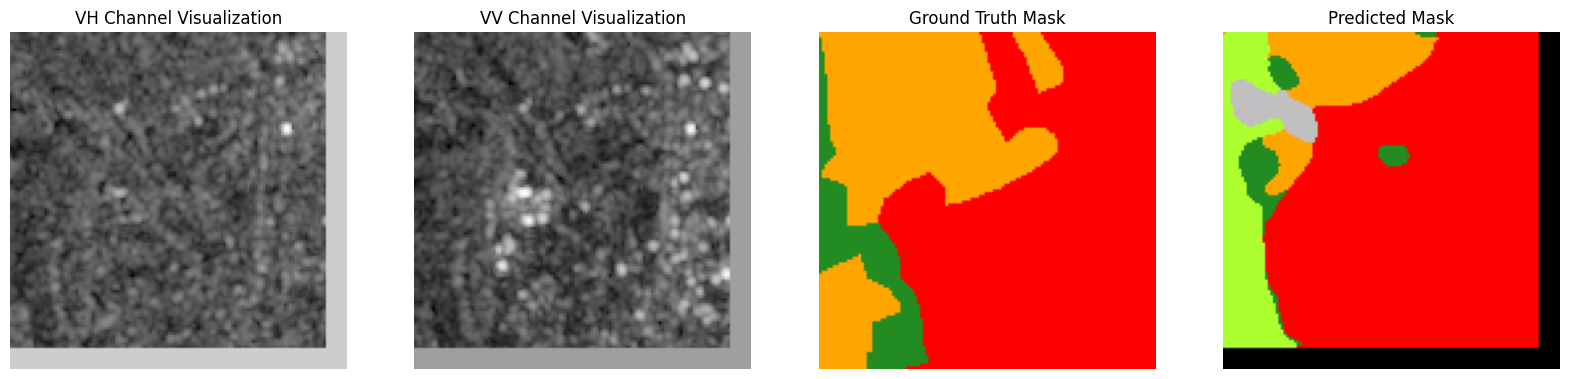

Image Key: S1B_IW_GRDH_1SDV_20170612T165809_33UUP_37_59, Reference Key: S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_37_59_reference_map


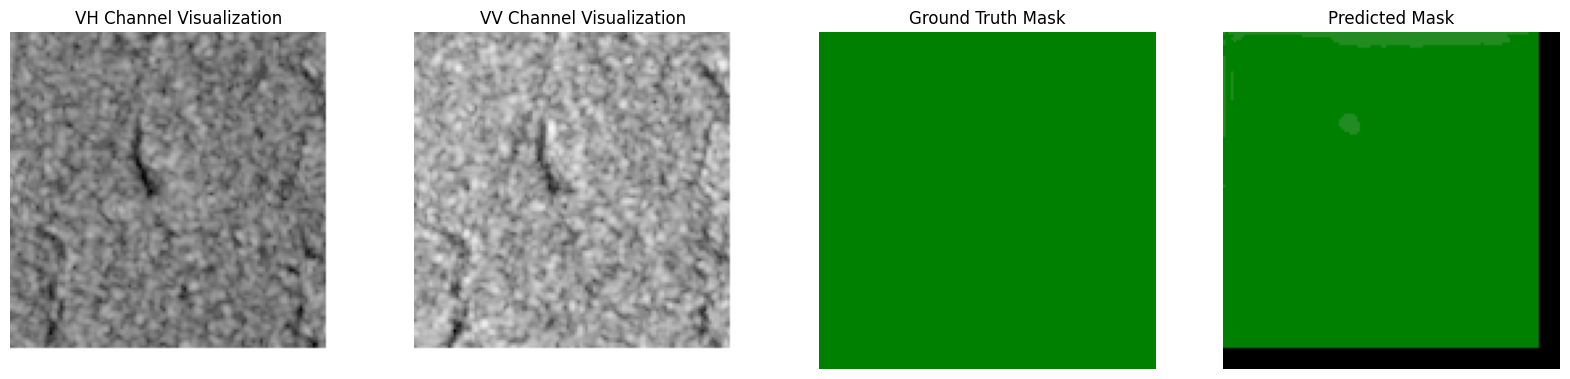

Image Key: S1B_IW_GRDH_1SDV_20170612T165809_33UUP_37_67, Reference Key: S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_37_67_reference_map


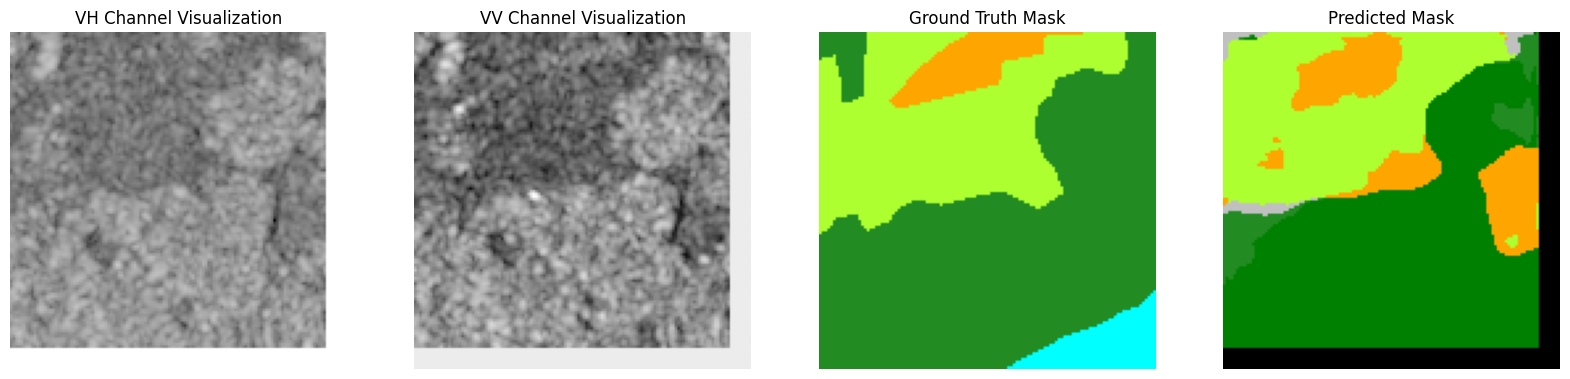

Image Key: S1B_IW_GRDH_1SDV_20170612T165809_33UUP_49_42, Reference Key: S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_49_42_reference_map


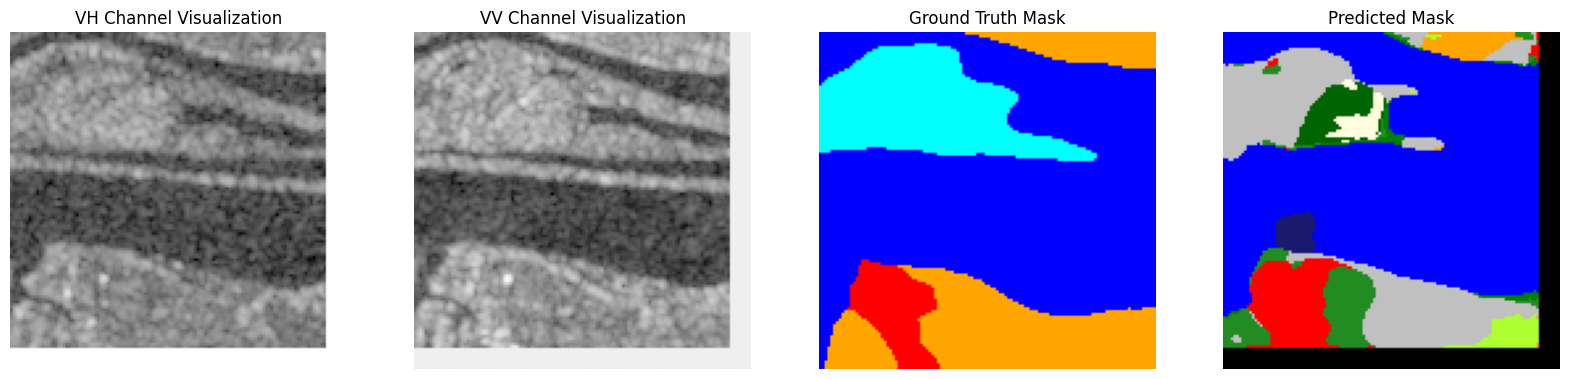

Image Key: S1B_IW_GRDH_1SDV_20170612T165809_33UUP_47_68, Reference Key: S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_47_68_reference_map


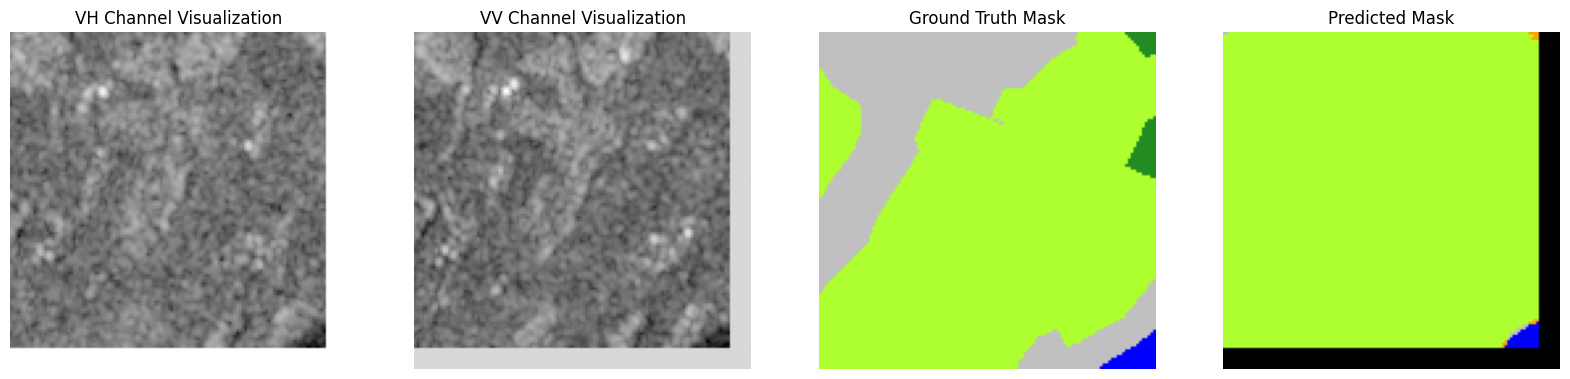

In [6]:
display_results(model128, test_loader128, lmdb_path, num_images=5, indices = indices)

## 120x120

In [12]:
test_loss, test_iou, test_f1 = calculate_scores(model_120_full, test_loader, device, 20)

Calculating scores: 100%|██████████| 7490/7490 [05:24<00:00, 23.11it/s]

Test Loss: 2.4978304168729184, Test IoU: 0.46034262112313223, Test F1: 0.6018778380862025


[458, 155, 163, 424, 396]
Image Key: S1B_IW_GRDH_1SDV_20170612T165809_33UUP_50_50, Reference Key: S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_50_50_reference_map


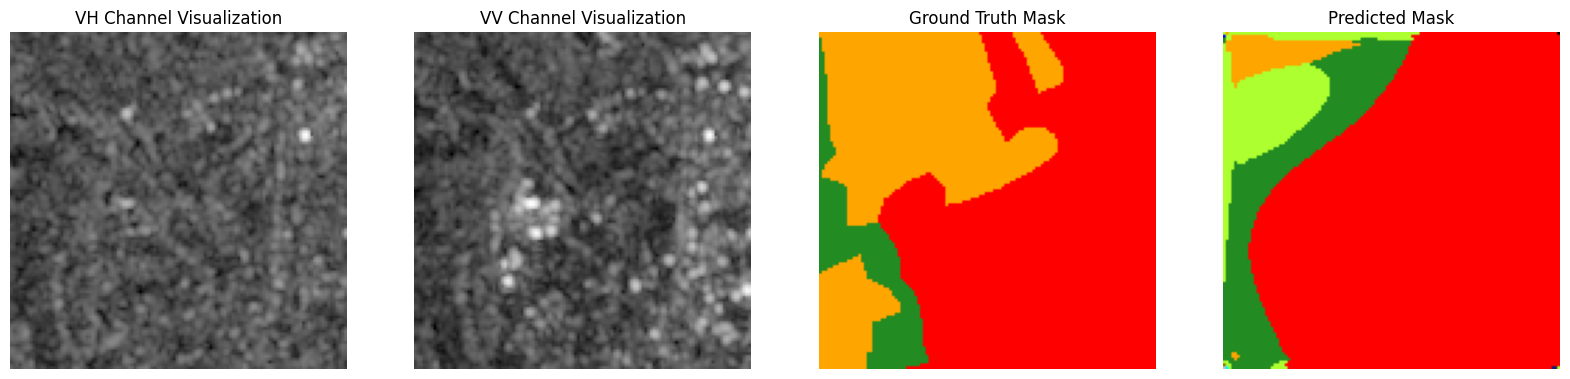

Image Key: S1B_IW_GRDH_1SDV_20170612T165809_33UUP_37_59, Reference Key: S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_37_59_reference_map


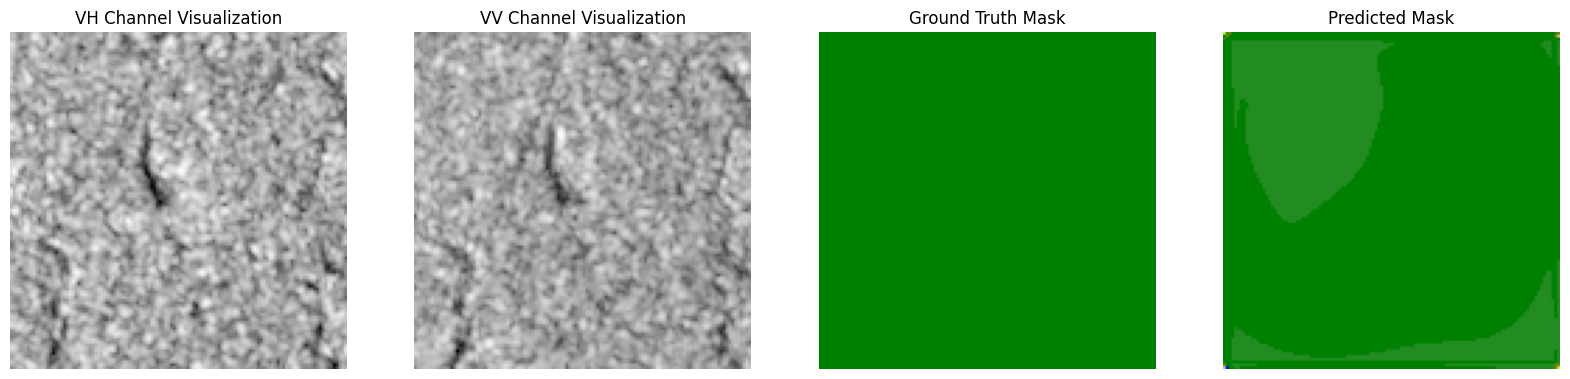

Image Key: S1B_IW_GRDH_1SDV_20170612T165809_33UUP_37_67, Reference Key: S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_37_67_reference_map


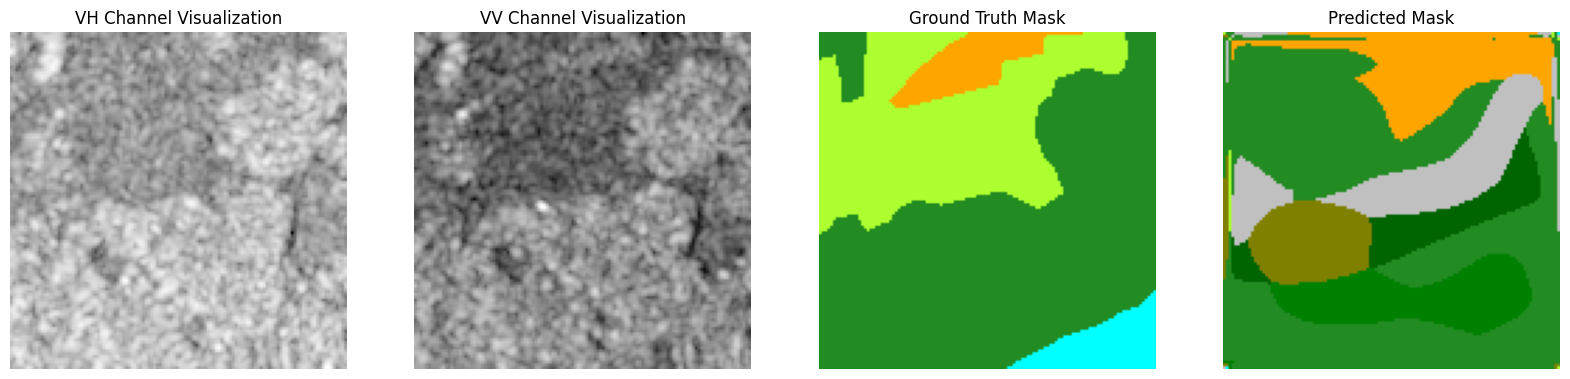

Image Key: S1B_IW_GRDH_1SDV_20170612T165809_33UUP_49_42, Reference Key: S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_49_42_reference_map


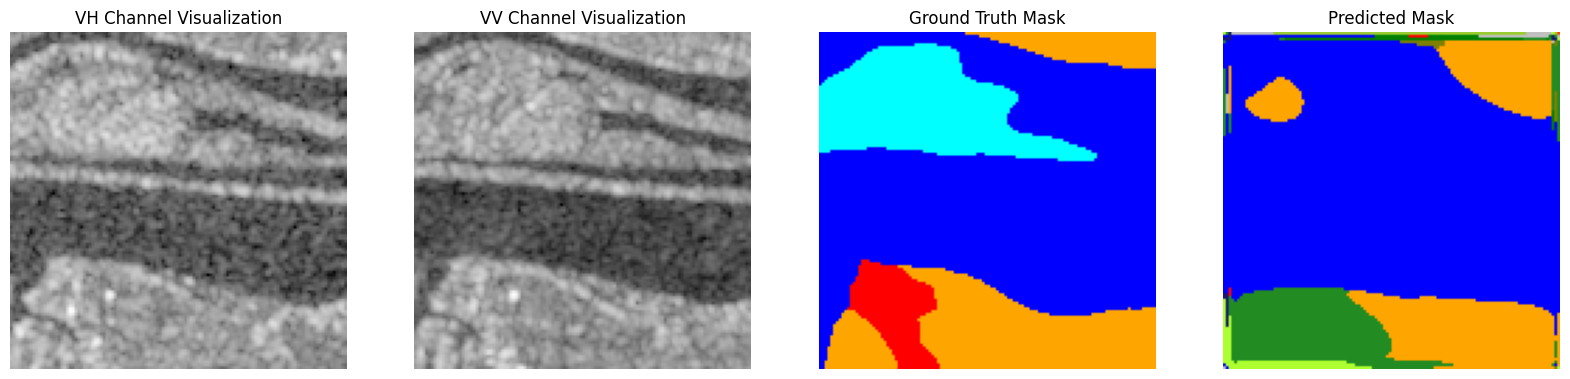

Image Key: S1B_IW_GRDH_1SDV_20170612T165809_33UUP_47_68, Reference Key: S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_47_68_reference_map


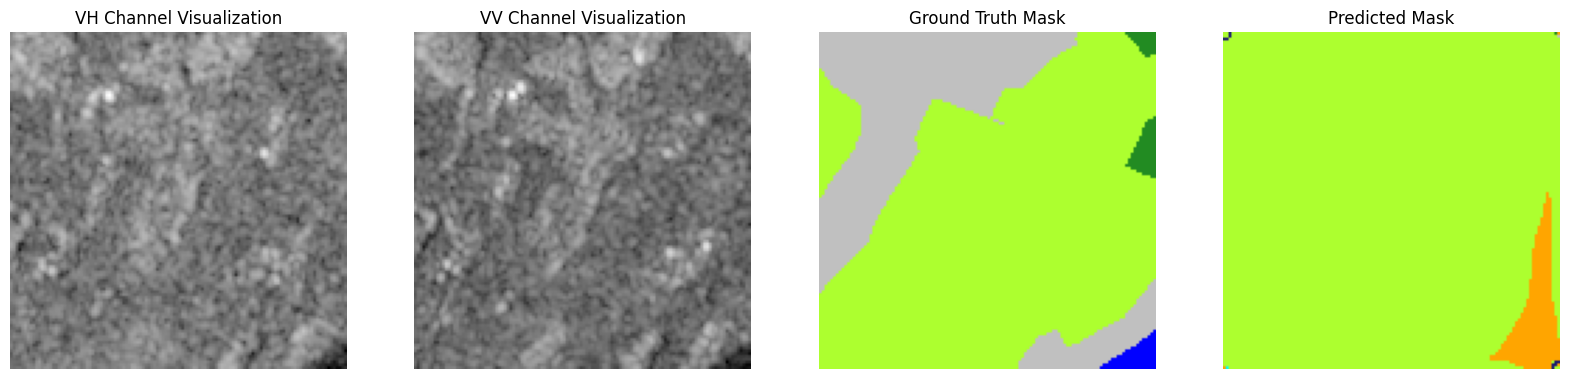

In [13]:
display_results(model120, test_loader, lmdb_path, num_images=5, indices = indices)

## 120x120 short

In [9]:
test_loss, test_iou, test_f1 = calculate_scores(model_120short, test_loader, device, 20)

Calculating scores: 100%|██████████| 7490/7490 [05:13<00:00, 23.86it/s]

Test Loss: 2.6699033209733236, Test IoU: 0.32437716505906256, Test F1: 0.44322260810347675


[458, 155, 163, 424, 396]
Image Key: S1B_IW_GRDH_1SDV_20170612T165809_33UUP_50_50, Reference Key: S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_50_50_reference_map


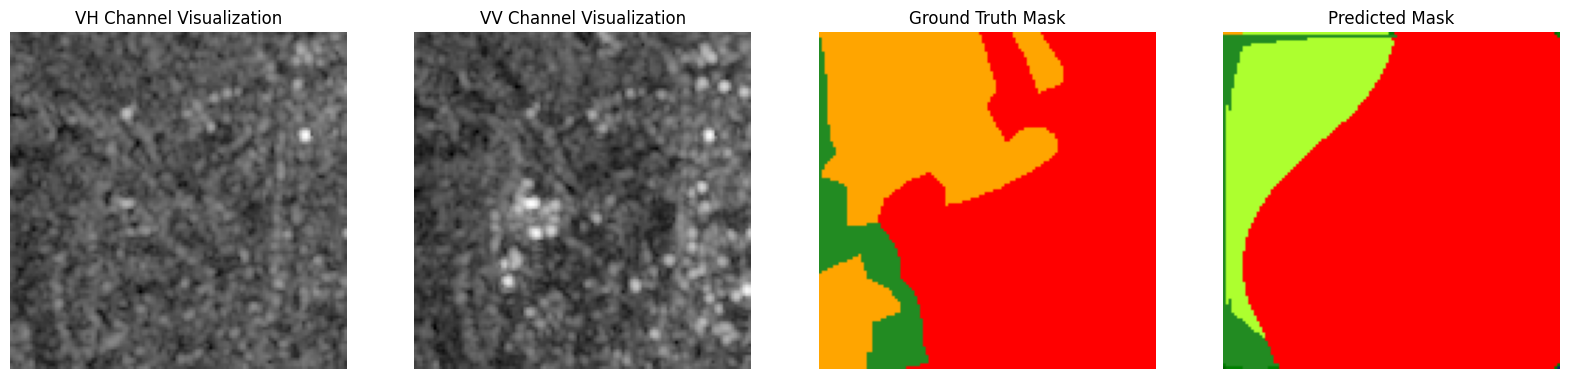

Image Key: S1B_IW_GRDH_1SDV_20170612T165809_33UUP_37_59, Reference Key: S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_37_59_reference_map


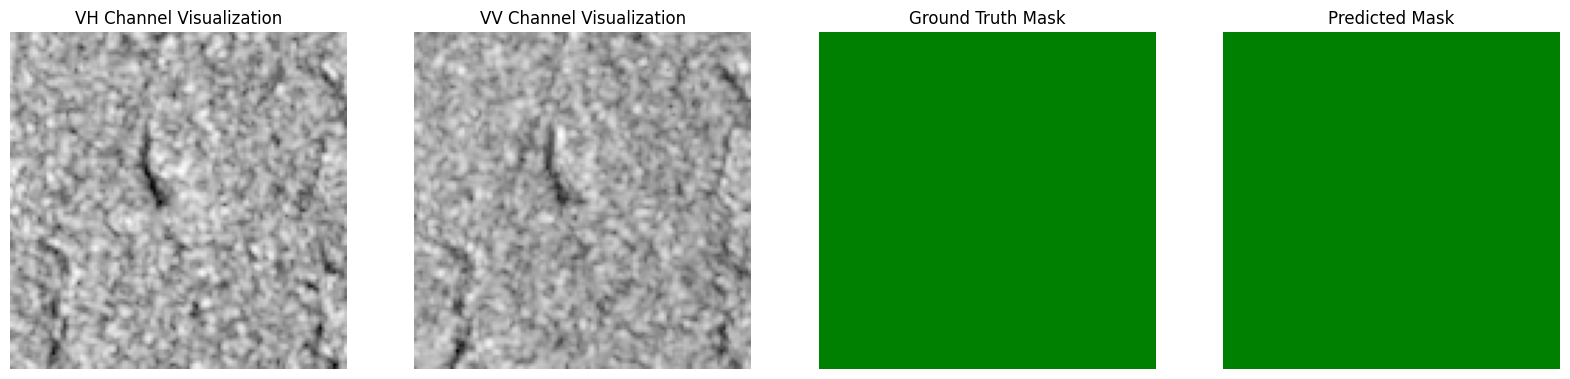

Image Key: S1B_IW_GRDH_1SDV_20170612T165809_33UUP_37_67, Reference Key: S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_37_67_reference_map


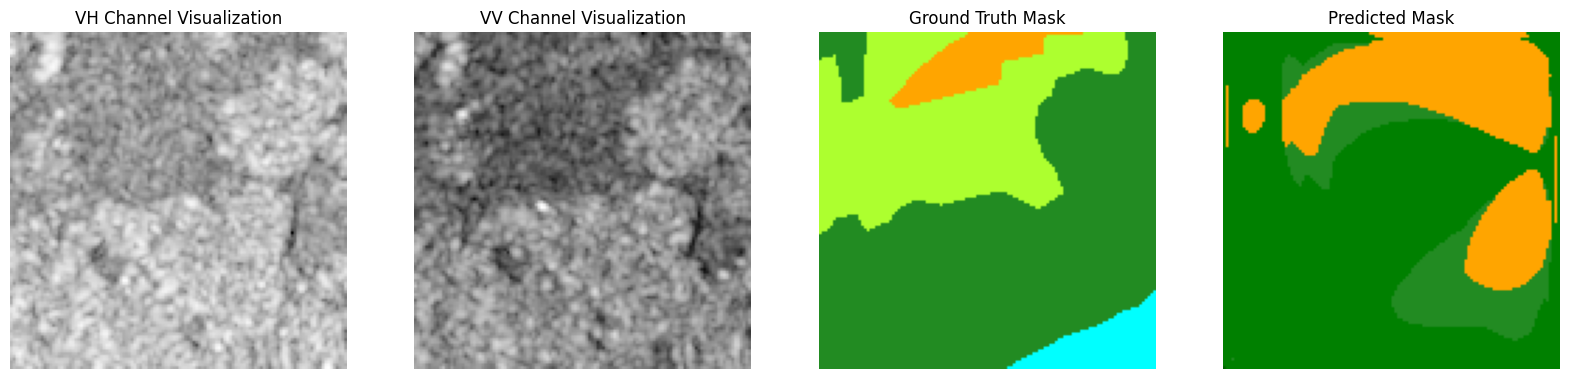

Image Key: S1B_IW_GRDH_1SDV_20170612T165809_33UUP_49_42, Reference Key: S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_49_42_reference_map


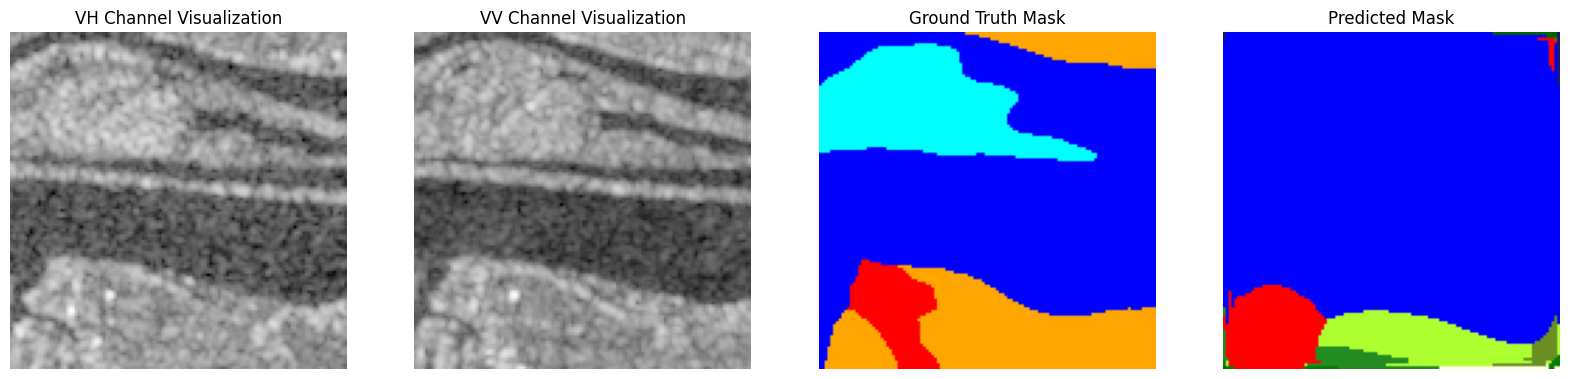

Image Key: S1B_IW_GRDH_1SDV_20170612T165809_33UUP_47_68, Reference Key: S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_47_68_reference_map


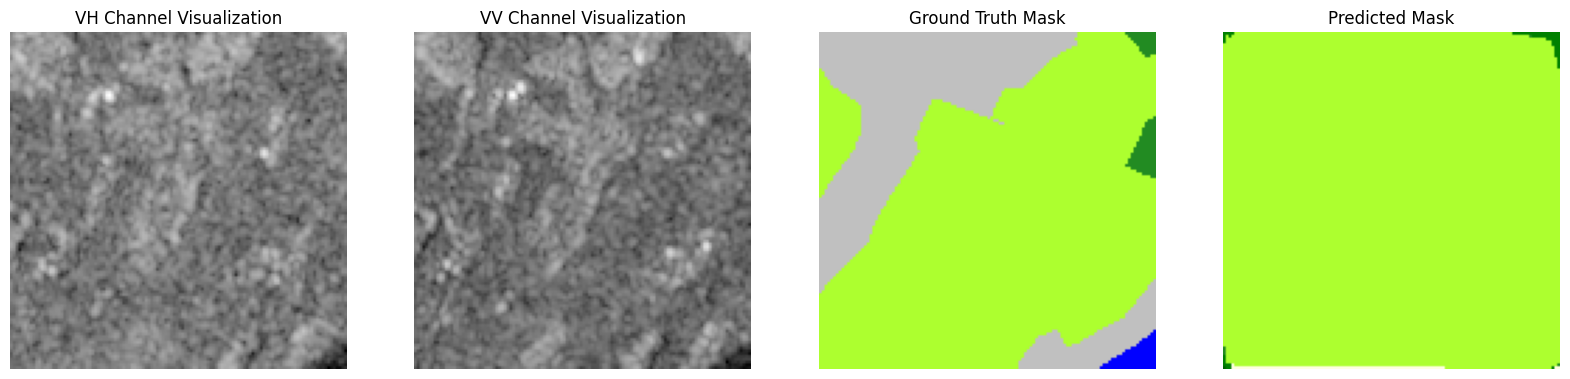

In [10]:
display_results(model_120short, test_loader, lmdb_path, num_images=5, indices = indices)

## Untrained 120x120

In [35]:
test_loss, test_iou, test_f1 = calculate_scores(model_untrained, test_loader, device, 20)

Calculating scores:   0%|          | 0/7490 [00:00<?, ?it/s]c:\Users\Jean\anaconda3\envs\ActivationPrototypes_SARSeg\lib\site-packages\torch\nn\modules\module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
Calculating scores: 100%|██████████| 7490/7490 [09:02<00:00, 13.82it/s] 

Test Loss: 2.9957285266056237, Test IoU: 0.04165951707474295, Test F1: 0.07435968732132507


[96231]
Image Key: S1A_IW_GRDH_1SDV_20180421T165021_33TWN_61_58, Reference Key: S2B_MSIL2A_20180421T100029_N9999_R122_T33TWN_61_58_reference_map


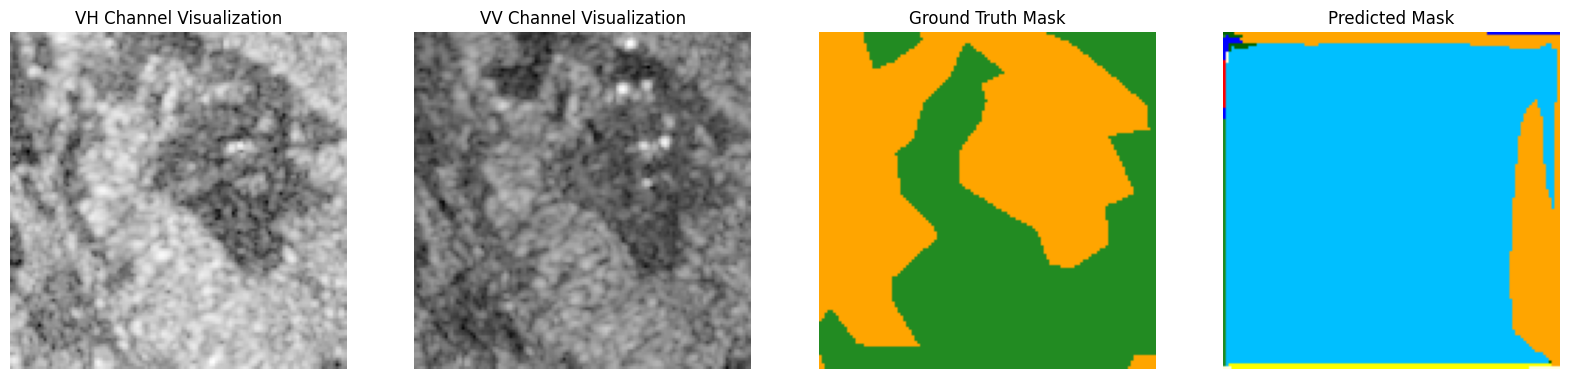

In [38]:
display_results(model_untrained, test_loader, lmdb_path, num_images=1)

## Check multiple 120 epochs

Epoch 15


Calculating scores: 100%|██████████| 7490/7490 [06:14<00:00, 20.00it/s]


Test Loss: 2.535835267068229, Test IoU: 0.42772090671265695, Test F1: 0.5621443473914257


Epoch 16


Calculating scores: 100%|██████████| 7490/7490 [08:28<00:00, 14.73it/s]


Test Loss: 2.5096725049419937, Test IoU: 0.45124452629180073, Test F1: 0.5903407156994649


Epoch 17


...

Test Loss: 2.5033446018781778, Test IoU: 0.4542391963804188, Test F1: 0.5935329873040219


Epoch 19


Calculating scores: 100%|██████████| 7490/7490 [09:26<00:00, 13.22it/s]


Test Loss: 2.4978304184326663, Test IoU: 0.46034262112313223, Test F1: 0.6018778380862025


Epoch 20


Calculating scores: 100%|██████████| 7490/7490 [09:47<00:00, 12.74it/s]


Test Loss: 2.512218297244073, Test IoU: 0.4437937946540014, Test F1: 0.5828587086659884


[49948, 31630, 106109]
Image Key: S1A_IW_GRDH_1SDV_20180526T045642_34WFU_63_65, Reference Key: S2A_MSIL2A_20180526T100031_N9999_R122_T34WFU_63_65_reference_map


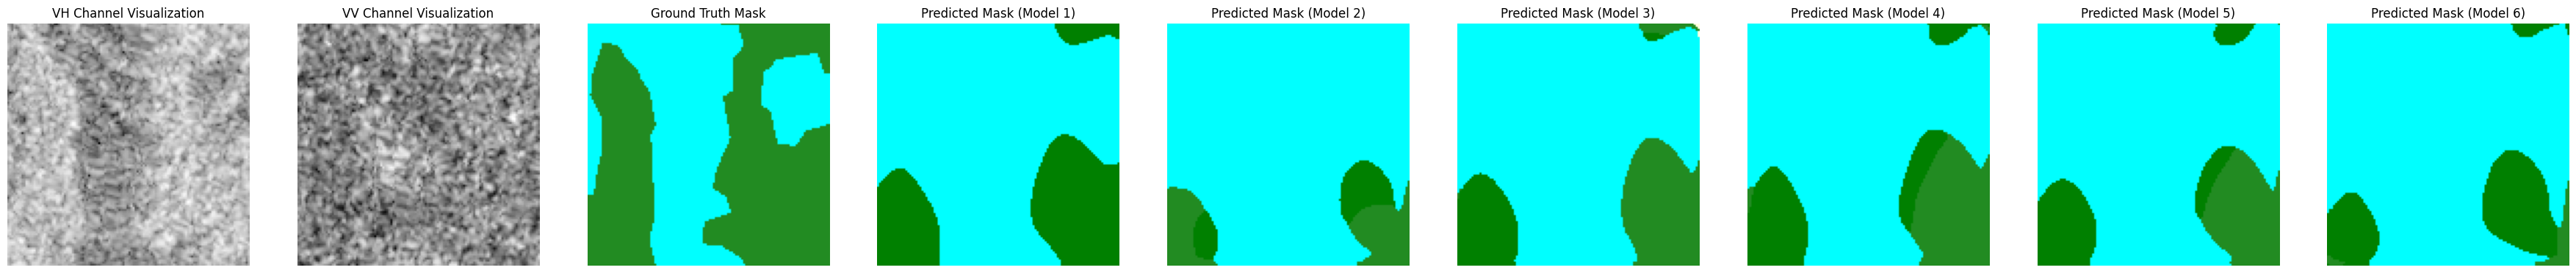

Image Key: S1A_IW_GRDH_1SDV_20171203T183450_29SNB_58_31, Reference Key: S2A_MSIL2A_20171201T112431_N9999_R037_T29SNB_58_31_reference_map


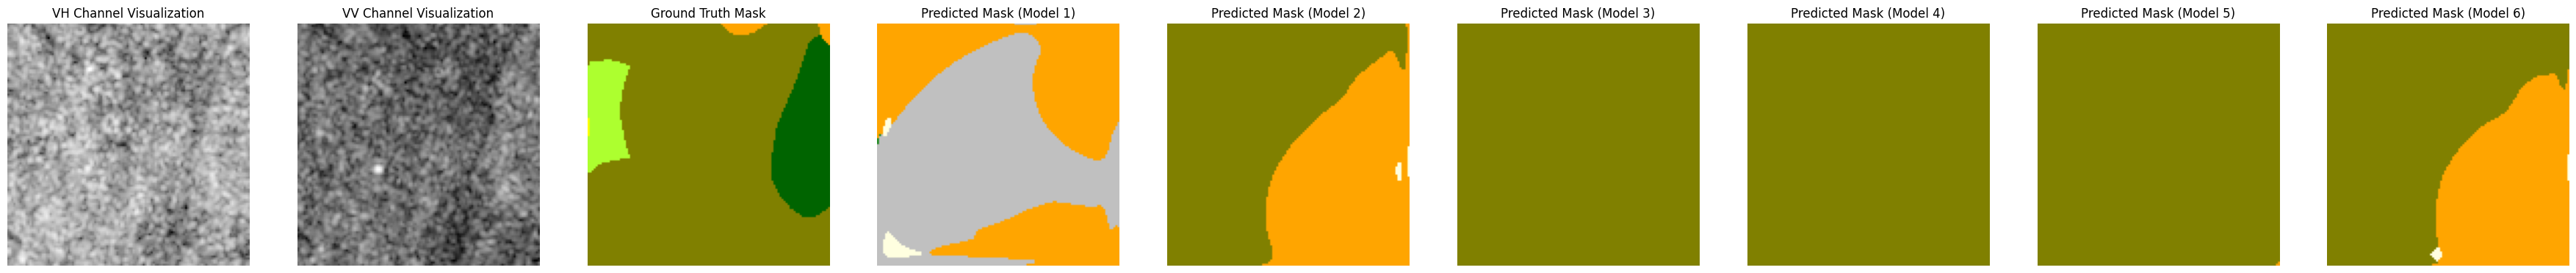

Image Key: S1B_IW_GRDH_1SDV_20180517T154802_35VNJ_56_58, Reference Key: S2B_MSIL2A_20180515T094029_N9999_R036_T35VNJ_56_58_reference_map


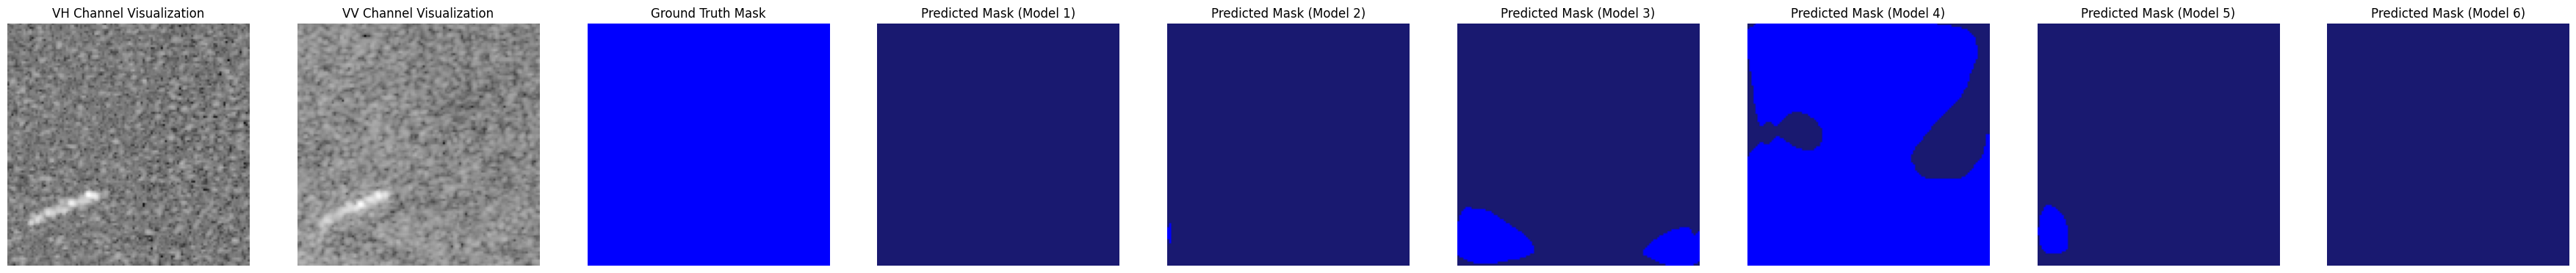

In [47]:
models = []

for epoch in range(15, 21):
    print(f"Epoch {epoch}")
    model_compare = load_from_checkpoint120(f"../models/full_120/unet120_full_epoch_{epoch}.pth").to(device)
    models.append(model_compare) 
    test_loss, test_iou, test_f1 = calculate_scores(model_compare, test_loader, device, 20)
    print("\n")

display_results2(models, test_loader, lmdb_path, num_images=3, indices = [49948, 31630, 106109])

[60917, 83832, 58604, 94574, 101098]
Image Key: S1A_IW_GRDH_1SDV_20170904T161304_34VDN_67_65, Reference Key: S2B_MSIL2A_20170906T101019_N9999_R022_T34VDN_67_65_reference_map


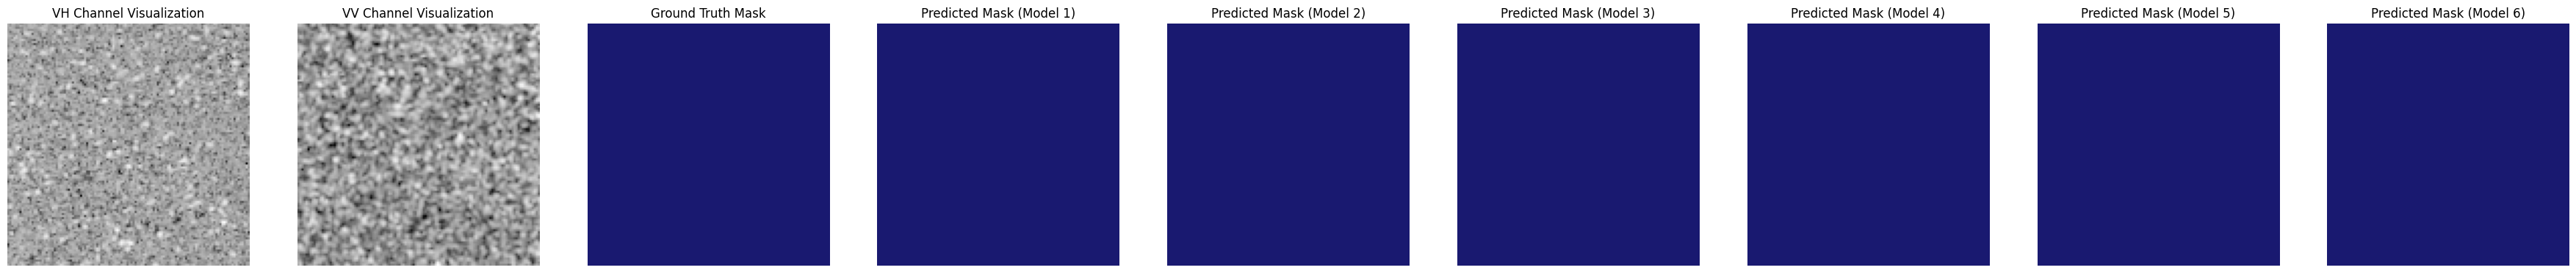

Image Key: S1B_IW_GRDH_1SDV_20171220T050937_33TWN_39_64, Reference Key: S2B_MSIL2A_20171219T095409_N9999_R079_T33TWN_39_64_reference_map


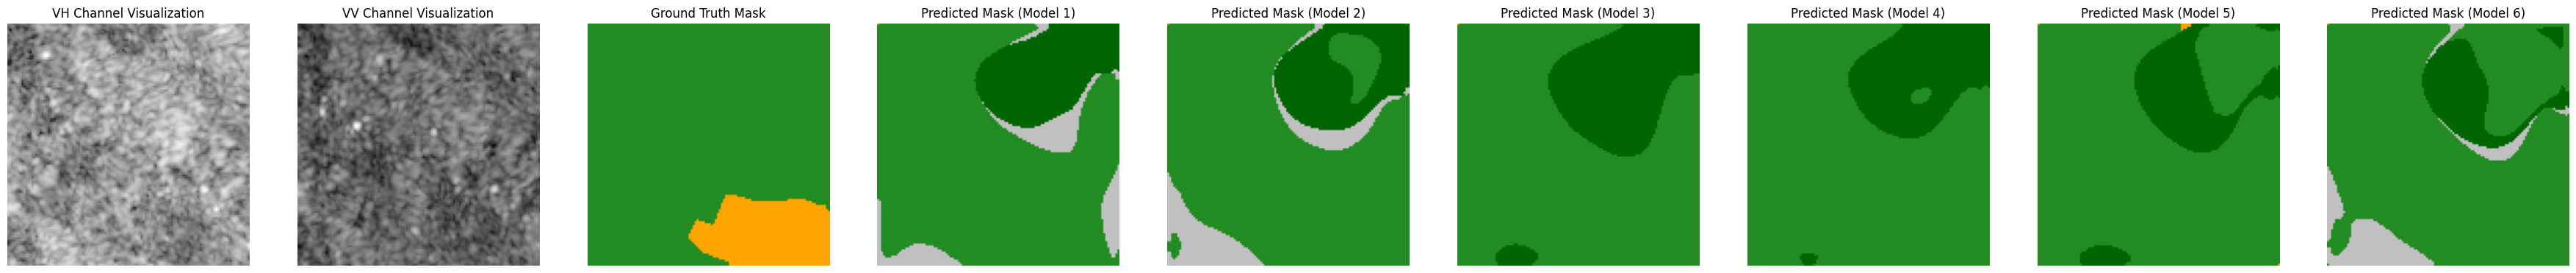

Image Key: S1A_IW_GRDH_1SDV_20170826T163327_34TEQ_33_39, Reference Key: S2B_MSIL2A_20170825T093029_N9999_R136_T34TEQ_33_39_reference_map


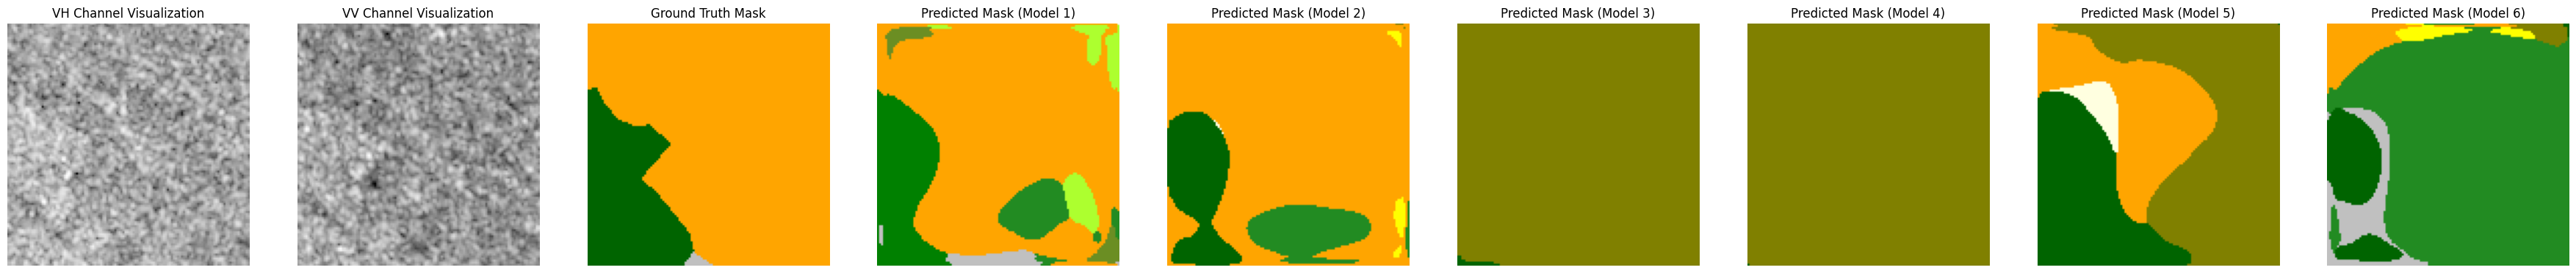

Image Key: S1A_IW_GRDH_1SDV_20180421T165046_33TWN_25_40, Reference Key: S2B_MSIL2A_20180421T100029_N9999_R122_T33TWN_25_40_reference_map


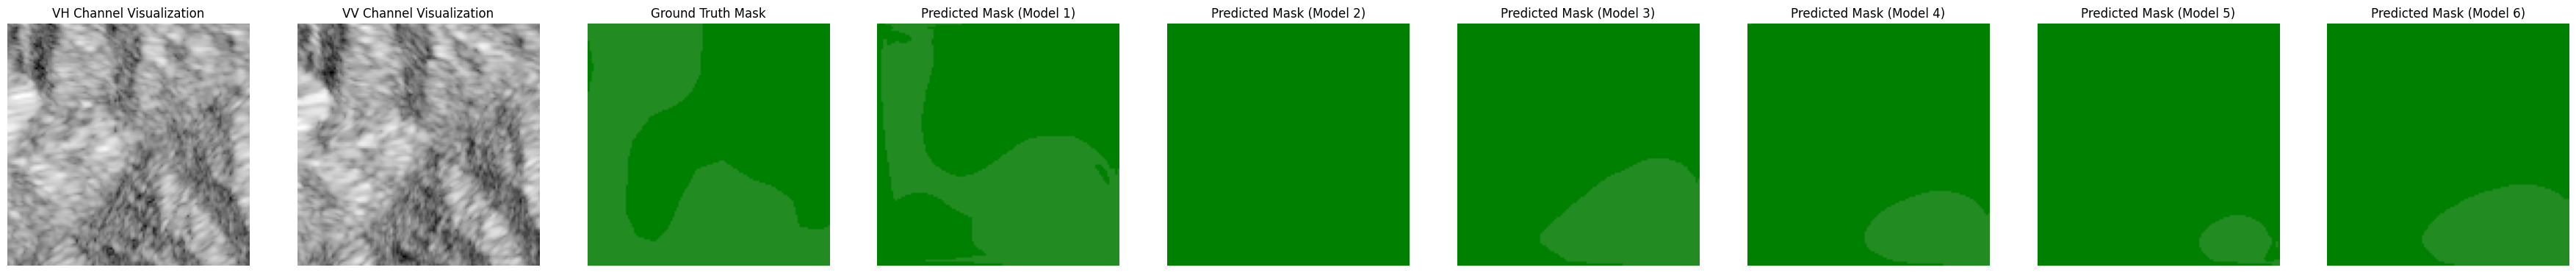

Image Key: S1A_IW_GRDH_1SDV_20180430T162450_34TEP_47_29, Reference Key: S2B_MSIL2A_20180502T093039_N9999_R136_T34TEP_47_29_reference_map


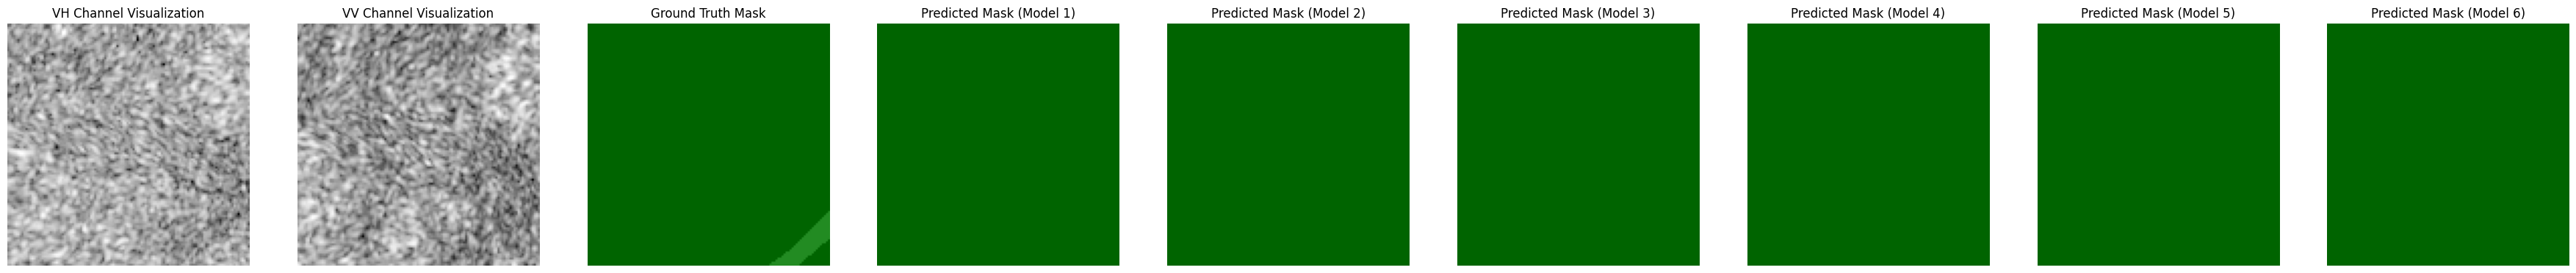

In [48]:
display_results2(models, test_loader, lmdb_path, num_images=5)

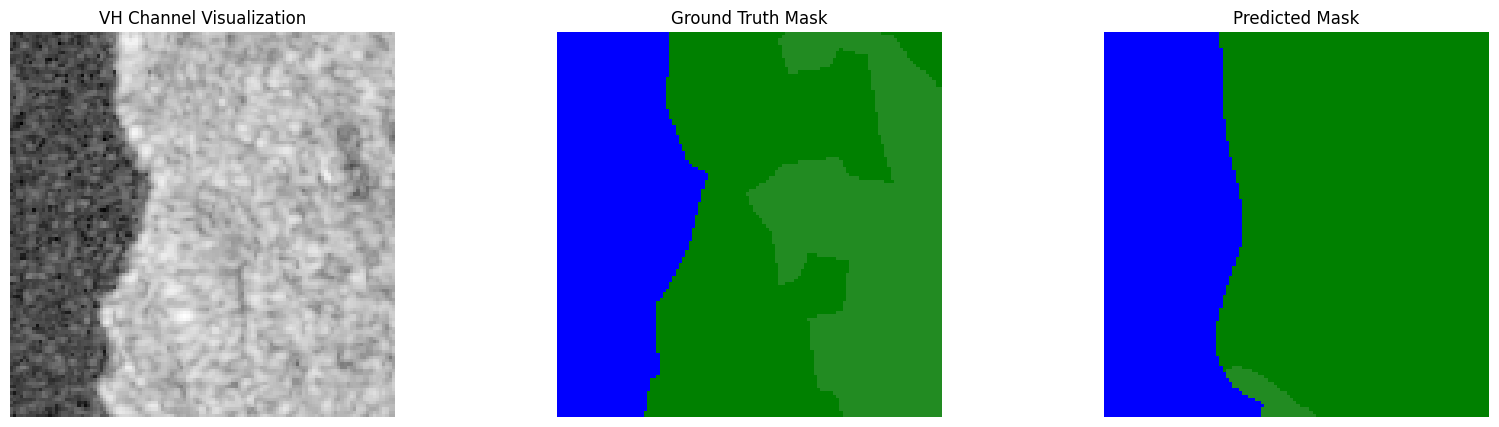

In [51]:
query_image_reference = 'S1B_IW_GRDH_1SDV_20180517T154802_35VNJ_55_62'
query_layer_name = 'encoder.layer4'  # Change to the layer you're analyzing

display_good_bad(model_120_full, lmdb_path, "S1B_IW_GRDH_1SDV_20180517T154802_35VNJ_55_62", "S2B_MSIL2A_20180515T094029_N9999_R036_T35VNJ_55_62_reference_map")
